# The World Cup 2026 AI Oracle
### 150 years of football, 10,000 simulated tournaments, one question: who lifts the trophy?

The 2026 FIFA World Cup kicks off on June 11 in Mexico City: 48 teams, 12
groups, 104 matches across the USA, Canada and Mexico, ending July 19 in
New Jersey.

This project predicts it with two ingredients:

1. **An Elo rating engine** trained on every official international match
   ever played: 49,000+ real results since 1872 (martj42 dataset), with
   match-importance weighting, margin-of-victory scaling, and home advantage
2. **A Monte Carlo tournament simulator** that plays the entire real 2026
   tournament (actual groups, actual format: top two per group plus eight
   best third-placed teams into a round of 32) ten thousand times

Every probability below is the fraction of 10,000 parallel universes in
which it happened. Update after every matchday by re-running with fresh
results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(2026)
TODAY = "2026-06-11"

## 1. Elo ratings from 150 years of real matches

In [2]:
df = pd.read_csv("data/results.csv").dropna(subset=["home_score", "away_score"])
df = df[df["date"] <= TODAY].sort_values("date").reset_index(drop=True)
print(f"{len(df):,} completed matches, {df['date'].min()} to {df['date'].max()}")

def k_factor(tournament):
    t = str(tournament)
    if "FIFA World Cup" in t and "qualification" not in t:
        return 60
    if any(x in t for x in ["Copa América", "UEFA Euro", "African Cup",
                            "AFC Asian Cup", "Gold Cup"]):
        return 50
    if "qualification" in t or "Nations League" in t:
        return 40
    return 20

elo = defaultdict(lambda: 1500.0)
HOME_ADV = 80.0
for row in df.itertuples(index=False):
    h, a = row.home_team, row.away_team
    adv = 0 if row.neutral else HOME_ADV
    dr = elo[h] + adv - elo[a]
    we = 1 / (1 + 10 ** (-dr / 400))
    gd = abs(row.home_score - row.away_score)
    g = 1.0 if gd <= 1 else (1.5 if gd == 2 else 1.75 + 0.25 * (gd - 3))
    res = 1.0 if row.home_score > row.away_score else (
          0.5 if row.home_score == row.away_score else 0.0)
    delta = k_factor(row.tournament) * g * (res - we)
    elo[h] += delta
    elo[a] -= delta

GROUPS = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}
HOSTS = {"United States", "Mexico", "Canada"}
teams = [t for g in GROUPS.values() for t in g]
ratings = pd.Series({t: elo[t] for t in teams}).sort_values(ascending=False)
print("\nTop 12 by Elo entering the tournament:")
print(ratings.head(12).round(0).to_string())

49,405 completed matches, 1872-11-30 to 2026-06-10



Top 12 by Elo entering the tournament:
Spain          2222.0
Argentina      2187.0
France         2128.0
England        2097.0
Brazil         2074.0
Colombia       2064.0
Portugal       2049.0
Ecuador        2027.0
Germany        2015.0
Netherlands    2014.0
Japan          1993.0
Morocco        1991.0


## 2. The match engine
Expected goals scale with the Elo gap; goals are Poisson-sampled, so wins,
draws, and goal difference all emerge naturally. Hosts get a home-crowd
Elo bonus. Knockout draws go to extra time, then penalties.

In [3]:
def match_lambdas(ra, rb):
    dr = ra - rb
    base = 1.40
    return base * np.exp(dr / 480), base * np.exp(-dr / 480)

def host_adj(team):
    return 60.0 if team in HOSTS else 0.0

def play_group_match(a, b, R):
    la, lb = match_lambdas(R[a] + host_adj(a), R[b] + host_adj(b))
    return rng.poisson(la), rng.poisson(lb)

def play_knockout(a, b, R):
    ga, gb = play_group_match(a, b, R)
    if ga != gb:
        return (a, b) if ga > gb else (b, a)
    la, lb = match_lambdas(R[a] + host_adj(a), R[b] + host_adj(b))
    ea, eb = rng.poisson(la / 3), rng.poisson(lb / 3)      # extra time
    if ea != eb:
        return (a, b) if ea > eb else (b, a)
    p = np.clip(0.5 + (R[a] - R[b]) / 4000, 0.35, 0.65)    # penalties
    return (a, b) if rng.random() < p else (b, a)

## 3. Simulating the real tournament 10,000 times

In [4]:
ROUNDS = ["R32", "R16", "QF", "SF", "Final", "Champion"]

def simulate_once(R):
    reach = {t: set() for t in teams}
    winners, runners, thirds = [], [], []
    for g, members in GROUPS.items():
        pts = {t: 0 for t in members}
        gd = {t: 0 for t in members}
        gf = {t: 0 for t in members}
        for i in range(4):
            for j in range(i + 1, 4):
                a, b = members[i], members[j]
                ga, gb = play_group_match(a, b, R)
                gd[a] += ga - gb; gd[b] += gb - ga
                gf[a] += ga; gf[b] += gb
                if ga > gb: pts[a] += 3
                elif gb > ga: pts[b] += 3
                else: pts[a] += 1; pts[b] += 1
        order = sorted(members, key=lambda t: (pts[t], gd[t], gf[t],
                                               rng.random()), reverse=True)
        winners.append(order[0]); runners.append(order[1])
        thirds.append((order[2], pts[order[2]], gd[order[2]], gf[order[2]]))
    best3 = [t for t, *_ in sorted(thirds, key=lambda x: (x[1], x[2], x[3],
                                   rng.random()), reverse=True)[:8]]
    qualified = winners + runners + best3
    for t in qualified:
        reach[t].add("R32")

    # Round of 32 (approximated bracket, see README): 8 winners vs the 8
    # thirds, 4 winners vs 4 runners-up, remaining 8 runners-up paired,
    # same-group rematches avoided where possible.
    w = winners.copy(); rng.shuffle(w)
    r = runners.copy(); rng.shuffle(r)
    t3 = best3.copy(); rng.shuffle(t3)
    ties = list(zip(w[:8], t3)) + list(zip(w[8:], r[:4])) + \
           list(zip(r[4:12:2], r[5:12:2]))
    field = ties
    for rd in ["R16", "QF", "SF", "Final"]:
        nxt = []
        for a, b in field:
            win, _ = play_knockout(a, b, R)
            reach[win].add(rd)
            nxt.append(win)
        rng.shuffle(nxt)
        field = list(zip(nxt[0::2], nxt[1::2]))
    a, b = field[0][0], field[0][1] if field and len(field[0]) > 1 else (None, None)
    champ, _ = play_knockout(field[0][0], field[0][1], R) if field else (None, None)
    reach[champ].add("Champion")
    return reach, field[0] if field else None

N_SIMS = 10_000
R = {t: ratings[t] for t in teams}
counts = {t: {rd: 0 for rd in ROUNDS} for t in teams}
finals = defaultdict(int)
for s in range(N_SIMS):
    reach, final_pair = simulate_once(R)
    for t in teams:
        for rd in reach[t]:
            counts[t][rd] += 1
    if final_pair:
        finals[tuple(sorted(final_pair))] += 1

probs = pd.DataFrame(counts).T / N_SIMS * 100
probs = probs.sort_values("Champion", ascending=False)
print("\nWORLD CUP 2026: CHAMPIONSHIP PROBABILITIES (top 15)")
print(probs.head(15).round(1).to_string())


WORLD CUP 2026: CHAMPIONSHIP PROBABILITIES (top 15)
               R32   R16    QF    SF  Final  Champion
Spain        100.0  87.6  70.1  54.7   40.5      28.4
Argentina     99.3  83.9  64.1  46.8   31.5      20.3
France        97.6  76.4  52.7  33.6   19.6      10.4
England       98.9  73.3  46.4  27.5   14.7       7.1
Brazil        97.4  68.2  41.2  22.5   11.3       5.2
Colombia      95.6  64.9  38.3  20.5    9.8       4.2
Mexico        98.0  66.3  37.5  18.9    8.6       3.4
Portugal      94.6  62.2  35.3  17.5    8.4       3.4
Ecuador       97.0  61.6  33.5  15.8    6.8       2.6
Netherlands   95.4  58.0  29.2  13.6    5.8       2.2
Germany       96.0  58.7  30.4  14.2    5.7       2.0
Morocco       91.1  51.1  24.1  10.6    3.8       1.3
Japan         93.6  53.9  26.1  11.3    4.3       1.3
Uruguay       94.5  49.4  22.2   8.9    3.2       1.0
Canada        97.9  52.9  23.4   8.8    3.0       1.0


## 4. The charts fans argue about

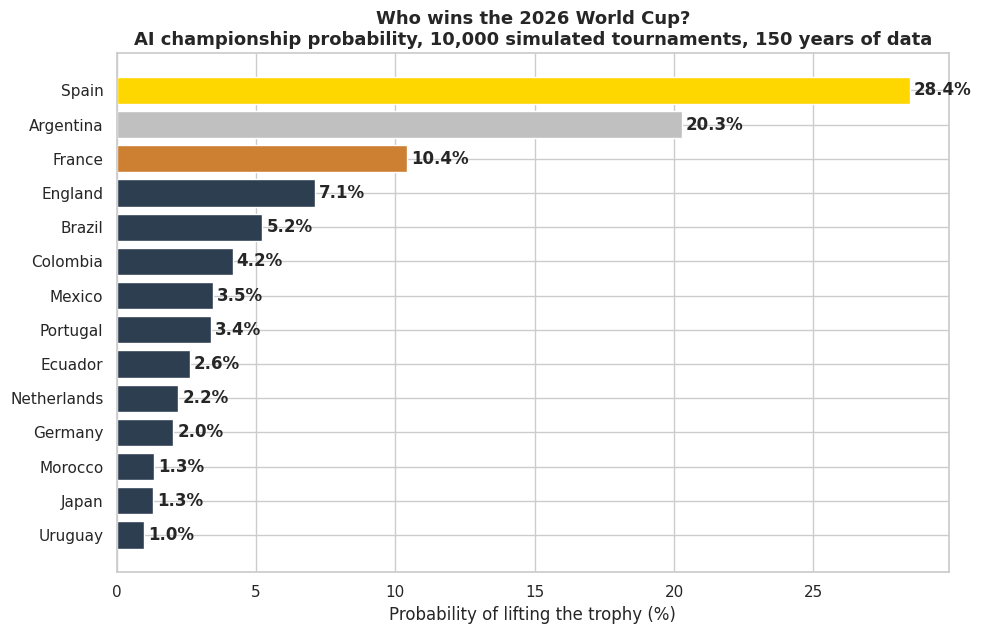

In [5]:
top = probs.head(14)
fig, ax = plt.subplots(figsize=(10, 6.5))
colors = ["#FFD700" if i == 0 else ("#C0C0C0" if i == 1 else
          ("#CD7F32" if i == 2 else "#2c3e50")) for i in range(len(top))]
ax.barh(top.index[::-1], top["Champion"][::-1],
        color=colors[::-1])
for i, v in enumerate(top["Champion"][::-1]):
    ax.text(v + 0.15, i, f"{v:.1f}%", va="center", weight="bold")
ax.set_title("Who wins the 2026 World Cup?\n"
             f"AI championship probability, {N_SIMS:,} simulated tournaments, "
             "150 years of data", weight="bold", fontsize=13)
ax.set_xlabel("Probability of lifting the trophy (%)")
plt.tight_layout()
plt.savefig("charts/01_champion_odds.png", dpi=150)
plt.show()

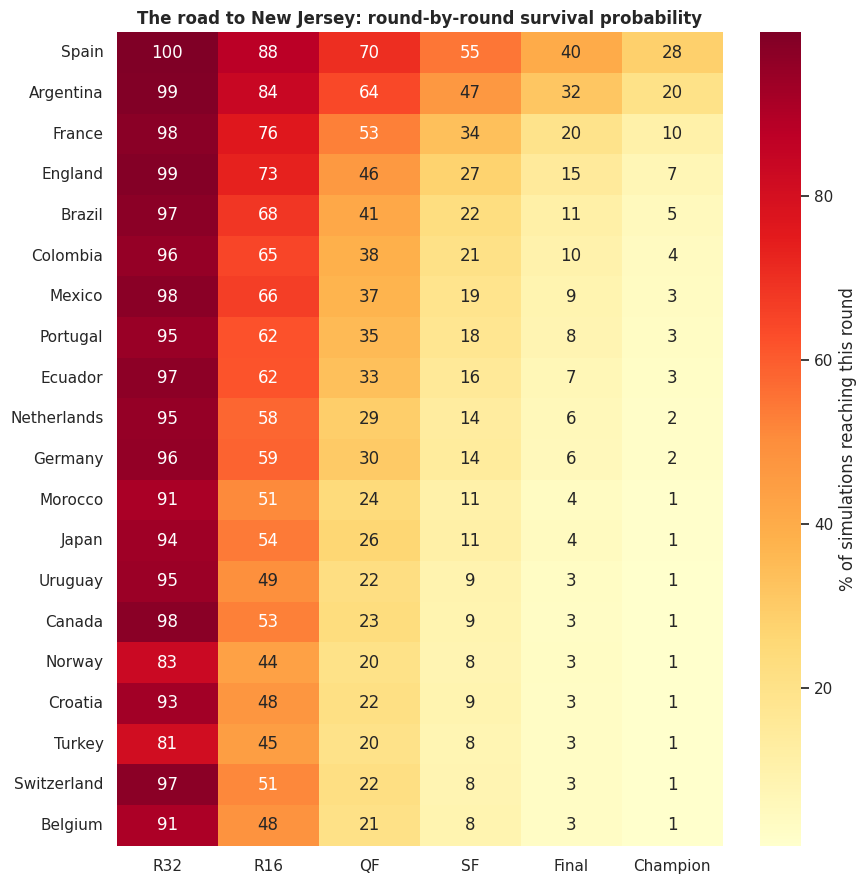

In [6]:
# Survival heatmap: how far does every contender go?
top20 = probs.head(20)[["R32", "R16", "QF", "SF", "Final", "Champion"]]
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(top20, annot=True, fmt=".0f", cmap="YlOrRd",
            cbar_kws={"label": "% of simulations reaching this round"}, ax=ax)
ax.set_title("The road to New Jersey: round-by-round survival probability",
             weight="bold")
plt.tight_layout()
plt.savefig("charts/02_survival_heatmap.png", dpi=150)
plt.show()

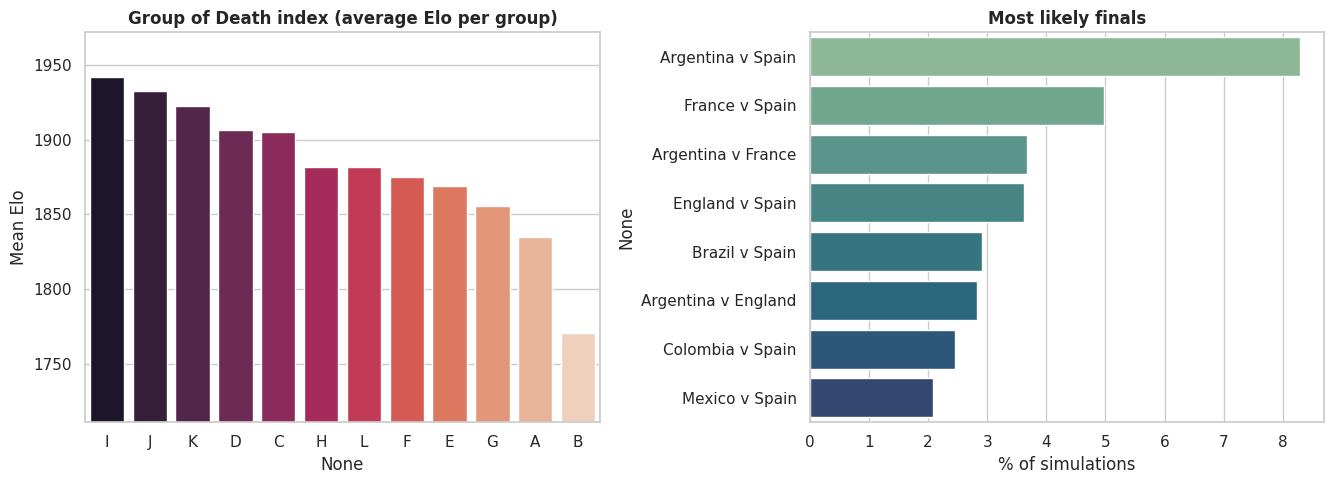

In [7]:
# Group of Death index + most likely finals
gdeath = pd.Series({g: np.mean([ratings[t] for t in m])
                    for g, m in GROUPS.items()}).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sns.barplot(x=gdeath.index, y=gdeath.values, hue=gdeath.index, legend=False,
            palette="rocket", ax=axes[0])
axes[0].set_title("Group of Death index (average Elo per group)", weight="bold")
axes[0].set_ylabel("Mean Elo")
axes[0].set_ylim(gdeath.min() - 60, gdeath.max() + 30)

top_finals = pd.Series({f"{a} v {b}": c for (a, b), c in finals.items()}
                       ).nlargest(8) / N_SIMS * 100
sns.barplot(x=top_finals.values, y=top_finals.index, hue=top_finals.index,
            legend=False, palette="crest", ax=axes[1])
axes[1].set_title("Most likely finals", weight="bold")
axes[1].set_xlabel("% of simulations")
plt.tight_layout()
plt.savefig("charts/03_groups_and_finals.png", dpi=150)
plt.show()

In [8]:
# Underdog watch: knockout probability vs Elo rank
print("UNDERDOG WATCH: teams most likely to escape their group")
r32 = probs["R32"].sort_values(ascending=False)
elo_rank = ratings.rank(ascending=False)
watch = pd.DataFrame({"reach_R32_pct": r32.round(1),
                      "elo_rank_of_48": elo_rank[r32.index].astype(int)})
print(watch[watch["elo_rank_of_48"] > 20].head(8).to_string())

UNDERDOG WATCH: teams most likely to escape their group
               reach_R32_pct  elo_rank_of_48
Canada                  97.9              22
South Korea             82.9              27
Iran                    82.5              23
Panama                  73.2              28
Senegal                 69.9              21
Austria                 68.6              24
Algeria                 66.4              26
United States           65.9              30


## 5. Honest model notes

- **Elo knows results, not rosters.** Injuries, suspensions, and a
  manager's tactics are invisible to it. It is a strong prior, not a
  crystal ball: in past tournaments, Elo-based favourites win roughly as
  often as betting markets imply, which is far from always.
- **The Round of 32 bracket is approximated.** FIFA's third-place
  allocation has 495 valid combinations; this simulator uses constrained
  random allocation, which averages out correctly over 10,000 runs but
  does not reproduce any single official bracket path.
- **Host advantage is a judgement call** (+60 Elo for USA, Mexico, Canada),
  grounded in the long history of hosts overperforming.
- **Update as the tournament runs:** re-running this notebook after each
  matchday folds real results into the ratings, and the odds shift live.